In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.datasets import make_circles, make_moons

# if nvidia gpu available use it --> TODO: add to the model and adjoint method such that it is supported
device = "cuda" if torch.cuda.is_available() else "cpu"

## 1. Generate Toy Datasets

In [33]:
# generate moon dataset
coord_moon, label_moon = make_moons(500, noise=0.025)

# generate circle dataset 
coord_circle, label_circle = make_circles(500, noise=0.025)

# dtype of dataset
print(type(coord_circle))

# dimension of data
print(coord_circle.shape)
print(label_circle.shape)

print(coord_circle[0])

<class 'numpy.ndarray'>
(500, 2)
(500,)
[-0.8471804 -0.4901234]


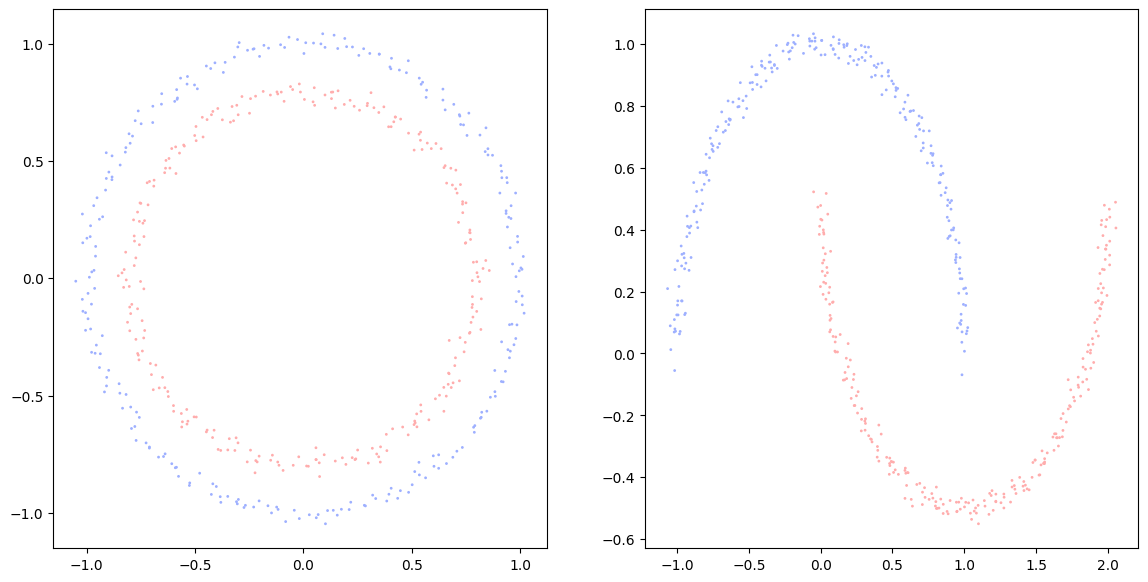

In [34]:
# plot datasets
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# plot circle data
ax[0].scatter(coord_circle[... , 0], coord_circle[... , 1], s=1, c=label_circle, cmap="berlin")

# plot moon data
ax[1].scatter(coord_moon[... , 0], coord_moon[... , 1], s=1, c=label_moon, cmap="berlin")

In [35]:
# Turn circle data into tensor dataset
x_circle_tensor = torch.from_numpy(coord_circle[..., 0]).float()
y_circle_tensor = torch.from_numpy(coord_circle[..., 1]).float()

circle_dataset = TensorDataset(x_circle_tensor, y_circle_tensor)

# Turn moon data into tensor dataset
x_moon_tensor = torch.from_numpy(coord_moon[..., 0]).float()
y_moon_tensor = torch.from_numpy(coord_moon[..., 1]).float()

moon_dataset = TensorDataset(x_moon_tensor, y_moon_tensor)

# Turn Datasets into Dataloader
circle_data = DataLoader(circle_dataset, batch_size=16)
moon_data = DataLoader(moon_dataset, batch_size=16)

## 2. ODE-Solver

### 2.1 Euler Method

In [36]:
# one step of euler method
def euler_step(dynamic, y_n, t_n, step_size):
    step = y_n + step_size * dynamic(y_n, t_n)
    return step

# euler ode solver
def euler_solver(dynamic, y_0, t_0, nb_steps, step_size):
    y_n, t_n = y_0, t_0

    # calculate steps until endstep
    for _ in range(nb_steps):
        y_n = euler_step(dynamic, y_n, t_n, step_size)
        t_n = t_n + step_size
    
    return y_n, t_n

### 2.2 Runge-Kutta method (RK4)

In [37]:
# Runge-Kutta implemenatation (RK4)
def rk4_step(dynamic, y_n, t_n, stepsize):
    # calculate k_n for n in [1, 2, 3, 4] for weighted average of the four increments
    k_1 = dynamic(y_n, t_n)
    k_2 = dynamic(y_n + k_1 * stepsize / 2, t_n + stepsize / 2)
    k_3 = dynamic(y_n + k_2 * stepsize / 2, t_n + stepsize / 2)
    k_4 = dynamic(y_n + stepsize * k_3, t_n + stepsize)

    # calculate step
    step = y_n + stepsize / 6 * (k_1 + 2*k_2 + 2*k_3 + k_4)
    return step

def rk4_solver(model, y_0, t_0, nb_steps, step_size):
    y_n, t_n = y_0, t_0

    # calculate steps until endstep
    for _ in range(nb_steps):
        y_n = rk4_step(model, y_n, t_n, step_size)
        t_n = t_n + step_size
    
    return y_n, t_n

### 2.3 Test ODE Solver

In [38]:
# analytical solution
# dy/dt = -y, y(t) = y_0 * exp(-t)
# dy/dt = 2t, y(t) = y_0 + t^2

def model_exp(y, t):
    """dy/dt = -y"""
    return -y

def model_linear(y, t):
    """dy/dt = 2"""
    return 2

In [39]:
# testing euler 
# case exp decay
y_0_exp = torch.tensor(1.0)
y_end_exp = euler_solver(model_exp, y_0_exp, t_0=0.0, nb_steps=1000, step_size=0.001)
expected_exp = torch.exp(torch.tensor(-1.0))

# case linear function
y_0_linear = torch.tensor(1.0)
y_end_linear = euler_solver(model_linear, y_0_linear, t_0=0.0, nb_steps=1000, step_size=0.001)
expected_linear = y_0_linear + 2

# case 2D input
y_0_2D = torch.ones(8, 2)
y_end_2D = euler_solver(model_exp, y_0_2D, t_0=0.0, nb_steps=10, step_size=0.1)

print(f"exp true: {expected_exp}, solver: {y_end_exp}")
print(f"linear true: {expected_linear}, solver: {y_end_linear}")
print(f"solver 2D: {y_end_2D}")

exp true: 0.3678794503211975, solver: (tensor(0.3677), 1.0000000000000007)
linear true: 3.0, solver: (tensor(3.0000), 1.0000000000000007)
solver 2D: (tensor([[0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487]]), 0.9999999999999999)


In [40]:
# testing rk4 
# case exp decay
y_0_exp = torch.tensor(1.0)
y_end_exp = rk4_solver(model_exp, y_0_exp, t_0=0.0, nb_steps=1000, step_size=0.001)
expected_exp = torch.exp(torch.tensor(-1.0))

# case linear function
y_0_linear = torch.tensor(1.0)
y_end_linear = rk4_solver(model_linear, y_0_linear, t_0=0.0, nb_steps=1000, step_size=0.001)
expected_linear = y_0_linear + 2

# case 2D input
y_0_2D = torch.ones(8, 2)
y_end_2D = rk4_solver(model_exp, y_0_2D, t_0=0.0, nb_steps=10, step_size=0.1)

print(f"exp true: {expected_exp}, solver: {y_end_exp}")
print(f"linear true: {expected_linear}, solver: {y_end_linear}")
print(f"solver 2D: {y_end_2D}")

exp true: 0.3678794503211975, solver: (tensor(0.3679), 1.0000000000000007)
linear true: 3.0, solver: (tensor(3.0000), 1.0000000000000007)
solver 2D: (tensor([[0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679]]), 0.9999999999999999)


## 3. Adjoint-based Backpropagation 

### 3.1 Custom Autograd Function for Adjoint Method

In [ ]:
# custom autograd.Function s.t. pytorch does not calculate computational graph for autograd
class AdjointSolver(torch.autograd.Function):

    # forward pass through the vectorfield-model
    @staticmethod
    def forward(ctx, model, y_0, t_0, t_end, nb_steps, solver):
        # calculate stepsize
        step_size = (t_end - t_0) / nb_steps

        # define state vector for initial problem with start of function and start of probability
        #log_p_0 = torch.log(distr(y_0))    # removed because for MLE we need backward direction and using this has no meaning. therefore just learning difference in probability is better
        delta_log_p_0 = torch.zeros(1)
        s_0 = torch.cat([y_0, delta_log_p_0.unsqueeze(0)])

        # create function to build system of ODEs
        def cat_dynamics(state, t):
            z_0 = state[:-1]

            # calculate gradient for trace
            with torch.enable_grad():
                z = z_0.detach().requires_grad_(True)
                dz_dt = model(z, t)

                grad_trace = 0
                for i in range(len(dz_dt)):
                    grad_trace += torch.autograd.grad(dz_dt[i], z, retain_graph=True)[0][i]
                
            return torch.cat([dz_dt.detach(), -grad_trace.detach().unsqueeze(0)])


        # solve initial value problem
        s_end = solver(cat_dynamics, s_0, t_0, nb_steps, step_size)[0]

        # safe variables for backward step
        ctx.model = model
        ctx.save_for_backward(s_end, s_0, y_0)
        ctx.t_0 = t_0
        ctx.t_end = t_end
        ctx.nb_steps = nb_steps
        ctx.solver = solver

        return s_end
    
    # backward pass with adjoint vectorfield to get derivative of loss in respect to param of model
    @staticmethod
    def backward(ctx, dL_ds):
        # import saved variables from forwardpass
        model = ctx.model
        s_end, s_0, y_0, = ctx.saved_tensors
        t_0 = ctx.t_0
        t_end = ctx.t_end
        nb_steps = ctx.nb_steps
        solver = ctx.solver

        # define state vector for initial problem with backwart y dynamic, adjoint dynamic and Loss-grad dynamic
        num_params = sum(p.numel() for p in model.parameters())
        a_end = dL_ds[:-1]
        y_end = s_end[:-1]
        h_0 = torch.cat([y_end, a_end, torch.zeros(num_params)])

        # calculate lenght of individual dynamics state
        lenght_a = len(a_end)
        lenght_y = len(y_end)

        def cat_dynamics(state, t):
            # define the states
            z_0 = state[:lenght_y]
            a_0 = state[lenght_y:lenght_y + lenght_a]

            # calculate gradients
            with torch.enable_grad():
                z = z_0.detach().requires_grad_(True)
                dz_dt = model(z, t)

                # calculate the ODEs
                da_dt = -torch.autograd.grad(dz_dt, z, grad_outputs=a_0, retain_graph=True)[0]
                dL_dparam = torch.autograd.grad(dz_dt, model.parameters(), grad_outputs=a_0, retain_graph=True)
                dL_dparam = -torch.cat([g.flatten() for g in dL_dparam])
            
            return torch.cat([-dz_dt.detach().flatten(), da_dt.detach().flatten(), dL_dparam.detach().flatten()])
        
        # calculate stepsize
        step_size = (t_end - t_0) / nb_steps

        # solve initial value problem of cat augmented
        h_end = solver(cat_dynamics, h_0, t_end, nb_steps, -step_size)[0]

        dy0_dt = h_end[:lenght_y]
        dL_dparam = h_end[lenght_y + lenght_a:]

        # safe gradients of Loss
        idx = 0
        for param in model.parameters():
            # reshape into param shape
            n = param.numel()
            dif = dL_dparam[idx:idx+n].reshape(param.shape)

            # update gradients
            if param.grad is None:
                param.grad = dif.clone()
            else:
                param.grad += dif
            idx+=n
        
        # check if all params have grad now
        assert (idx == len(dL_dparam))

        # return all gradients of forward inputs
        return None, dy0_dt, None, None, None, None

### 3.2 Test Parts of Custom Autograd Function

In [42]:
# test function
W = torch.tensor([[1.0, 2.0], [3.0, 4.0]], requires_grad=True)
x = torch.randn(2, 1, requires_grad=True)
a_0 = torch.tensor([[1.0],[2.0]])


print(W.shape, x.shape)

def f(z, t):
    return W**2 @ z

torch.Size([2, 2]) torch.Size([2, 1])


In [43]:
# test forward dynamics
def cat_dynamics(state, t):
    z_0 = state #removed slicing because for testing not needed

    # calculate gradient for trace
    with torch.enable_grad():
        z = z_0.requires_grad_(True)
        dz_dt = f(z, t)

        grad_trace = 0
        for i in range(len(dz_dt)):
            grad_trace += torch.autograd.grad(dz_dt[i], z, retain_graph=True)[0][i]
                
    return torch.cat([dz_dt.detach(), -grad_trace.unsqueeze(0)])

# calculate trace of jacobian
trace_grad_f = cat_dynamics(x, 0)[-1]

print("== trace ==")
print(f"-tr(W): {(-W**2).trace()}")
print(f"cat_dynamic: {trace_grad_f}")

== trace ==
-tr(W): -17.0
cat_dynamic: tensor([-17.])


In [44]:
# test shapes
x = torch.randn(2, 1)
y = torch.rand(1, 2)

print(x)
print(y)

tensor([[-0.4004],
        [ 2.4840]])
tensor([[0.0470, 0.5588]])


In [45]:
# test backward dynamic

def cat_dynamics(state, t):
    # define the states
    z_0 = state # removed slicing because for testing not needed

    # calculate gradients
    with torch.enable_grad():
        z = z_0.detach().requires_grad_(True)
        dz_dt = f(z, t)

        # calculate the ODEs
        da_dt = -torch.autograd.grad(dz_dt, z, grad_outputs=a_0, retain_graph=True)[0]
        dL_dparam = torch.autograd.grad(dz_dt, [W], grad_outputs=a_0, retain_graph=True)
        dL_dparam = -torch.cat([g.flatten() for g in dL_dparam])
            
    return torch.cat([-dz_dt.detach().flatten(), da_dt.detach().flatten(), dL_dparam.detach().flatten()])

gradients = cat_dynamics(x, 0)
dz_adj  = gradients[:2]        # -dz/dt
da_adj  = gradients[2:4]       # da/dt
dW_adj  = gradients[4:]        # dL/dW flat

# calculate refrence directly with pytorch
z_ref = x.detach().requires_grad_(True)
W_ref = W.detach().requires_grad_(True)

dz_dt_ref = W_ref**2 @ z_ref   # shape [2,1]

loss = (a_0 * dz_dt_ref).sum()
loss.backward()

dz_ref = z_ref.grad.flatten()   # dL/dz
dW_ref = W_ref.grad.flatten()   # dL/dW

print("=== da/dt ===")
print(f"cat_dynamic:  {da_adj}")
print(f"Autograd: {-dz_ref}")
print(f"error: {(da_adj - (-dz_ref)).abs().max():.6f}")
print()

print("=== dL/dW ===")
print(f"cat_dynamic:  {dW_adj}")
print(f"Autograd: {-dW_ref}")
print(f"error: {(dW_adj - (-dW_ref)).abs().max():.6f}")

=== da/dt ===
cat_dynamic:  tensor([-19., -36.])
Autograd: tensor([-19., -36.])
error: 0.000000

=== dL/dW ===
cat_dynamic:  tensor([  0.8008,  -9.9358,   4.8047, -39.7433])
Autograd: tensor([  0.8008,  -9.9358,   4.8047, -39.7433])
error: 0.000000


## 4. Model Initialization

In [ ]:
# make vector field model
class MLPVectorField(nn.Module):
    def __init__(self, dim, hidden):
        super().__init__()
        # define 1 hidden layer MLP for vector field
        self.net = nn.Sequential(
            nn.Linear(dim+1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, dim)
        )

    def forward(self, y, t):
        t_vec = t.unsqueeze(0)
        inp = torch.cat([y, t_vec])
        output = self.net(inp)
        return output
    

# define the neural ODE class
class NeuralODE(nn.Module):
    def __init__(self, resolution, dim=2, hidden=16):
        super().__init__()
        # MLP to learn vector field
        self.net = MLPVectorField(dim, hidden)
        # safe how many steps should be made to solve ODE
        self.resolution = resolution

    def forward(self, y_0, t_0, t_end, solver):
        adjoint_forward = AdjointSolver().apply
        # calculate
        output = adjoint_forward(self.net, y_0, t_0, t_end, self.resolution, solver)
        y_end = output[:-1]
        y_prob = output[-1]
        
        return y_end, y_prob


## 5. Model Training

In [ ]:
# train step function for Neural ODEs
def make_train_step(model, optimizer, ode_solver):
    # define prior
    prior = torch.distributions.MultivariateNormal(torch.zeros_like(y_0), torch.eye(len(y_0)))

    # training function that gets created
    def train_step(y_end, t_0, t_end):
        optimizer.zero_grad()
        model.train()

        # calculate ODE Backward to use MLE on Gauss distr with connection to datapoints
        y_0, delta_prob = model(y_end, t_end, t_0, ode_solver)

        # calculate loss (MLE)
        y_0_prob = prior.log_prob(y_0)
        log_p = y_0_prob + delta_prob
        loss = -log_p

        # calculate gradient
        loss.backward()
        optimizer.step()

        return loss.item()
    
    return train_step

epochs = 100
lr = 1e-1

# init model
model = NeuralODE(10000, 2, 16)
print(model.state_dict())

# define an optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)

# create training function
training_step = make_train_step(model, optimizer, euler_solver)

train_history = []
eval_history = []
for e in range(epochs):
    print(f"Epoch: {e+1}")
#########################################################################################
    for x_batch, y_batch in train_loader:       #### TODO: need to make correct data loading and batches

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
#########################################################################################        
        # perform a train step
        loss_b = training_step(x_batch, y_batch)
        batch_loss.append(loss_b.item())
    
    loss_e = np.array(batch_loss).mean()
    train_history.append(loss_e)


#########################################################################################
    with torch.inference_mode():
        for x_val, y_val in eval_loader:
            
            x_val = x_val.to(device)
            y_val = y_val.to(device)

            # perform evaluation step                   TODO: change inferencing
            model.eval()
            y_pred = model(x_val)

            loss_eval = loss_fn(y_val, y_pred)
            eval_history.append(loss_b.item())
#########################################################################################

print()
print(model.state_dict())
print()

## 6. Model Evaluation/ Visualization